# Определение перспективного тарифа для телеком компании

Необходимо сделать предварительный анализ тарифов оператора сотовой связи на небольшой выборке клиентов. 
В файле данные пользователей. Нужно проанализировать поведение клиентов и сделать вывод — какой тариф лучше.

# Описание данных

Таблица **united_grouped** (информация о пользователях тарифных планов):
* **tariff** - название тарифного плана.
* **month** - номер месяца.
* **minutes_spent** - количество звонков и их длительность для каждого пользователя.
* **messages_sent** - количество сообщений для каждого пользователя.
* **gb_used** - объем веб-трафика в гигабайтах для каждого пользователя.
* **user_id** - уникальный идентификатор пользователя.
* **min_per_user** - среднее количество минут, используемое клиентом.
* **mes_per_user** - среднее количество смс, используемое клиентом.
* **gb_per_user** - среднее количество гигабайт, используемое клиентом.

# План работы:
    
Шаг 1. Откроем файл с данными 'all_combined.csv' и изучим общую информацию (количество строк и столбцов, проверим на дубликаты).
    
Шаг 2. Проанализируем данные:
- Опишем поведение клиентов, исходя из выборки (сколько минут разговора, сколько сообщений и какой объём интернет-трафика требуется пользователям каждого тарифа в месяц). 
- Посчитаем среднее количество, дисперсию и стандартное отклонение. 
- Построим гистограммы и опишем распределения.

### Анализ данных

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import warnings
warnings.filterwarnings('ignore')

<div class="alert alert-info"> 
Напишите в следующей ячейке код для чтения таблицы 'united_grouped' из файла 'all_combined.csv'
 </div>

In [8]:
united_grouped = pd.read_csv('all_combined.csv')# напишите в этой ячейке код для чтения таблицы 'united_grouped' из файла 'all_combined.csv'

<div class="alert alert-info"> 
Напишите в следующей ячейке код для отображения информации о таблице
 </div>

In [9]:
united_grouped.info()# напишите в этой ячейке код для отображения информации о таблице


<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tariff         24 non-null     str    
 1   month          24 non-null     int64  
 2   minutes_spent  24 non-null     int64  
 3   messages_sent  24 non-null     int64  
 4   gb_used        24 non-null     int64  
 5   user_id        24 non-null     int64  
 6   min_per_user   24 non-null     float64
 7   mes_per_user   24 non-null     float64
 8   gb_per_user    24 non-null     float64
dtypes: float64(3), int64(5), str(1)
memory usage: 1.8 KB


<div class="alert alert-info"> 
Напишите в следующей ячейке код для вывода первых 5 строк таблицы 'united_grouped'
 </div>

In [10]:
united_grouped.head(5)# напишите в этой ячейке код для вывода первых 5 строк таблицы 'united_grouped'


,tariff,month,minutes_spent,messages_sent,gb_used,user_id,min_per_user,mes_per_user,gb_per_user
0,smart,1,6931,620,297,34,203.9,18.2,8.7
1,smart,2,17324,1397,687,58,298.7,24.1,11.8
2,smart,3,30034,2453,1173,77,390.1,31.9,15.2
3,smart,4,41119,3443,1526,112,367.1,30.7,13.6
4,smart,5,54618,4762,2243,141,387.4,33.8,15.9


<div class="alert alert-info"> 
Напишите в следующей ячейке код для подсчета дубликатов в таблице 'united_grouped'
 </div>

In [11]:
united_grouped.duplicated().sum()# напишите в этой ячейке код для подсчета дубликатов в таблице 'united_grouped'
          

np.int64(0)

Таблицу для анализа использовать трудно, построим графики.

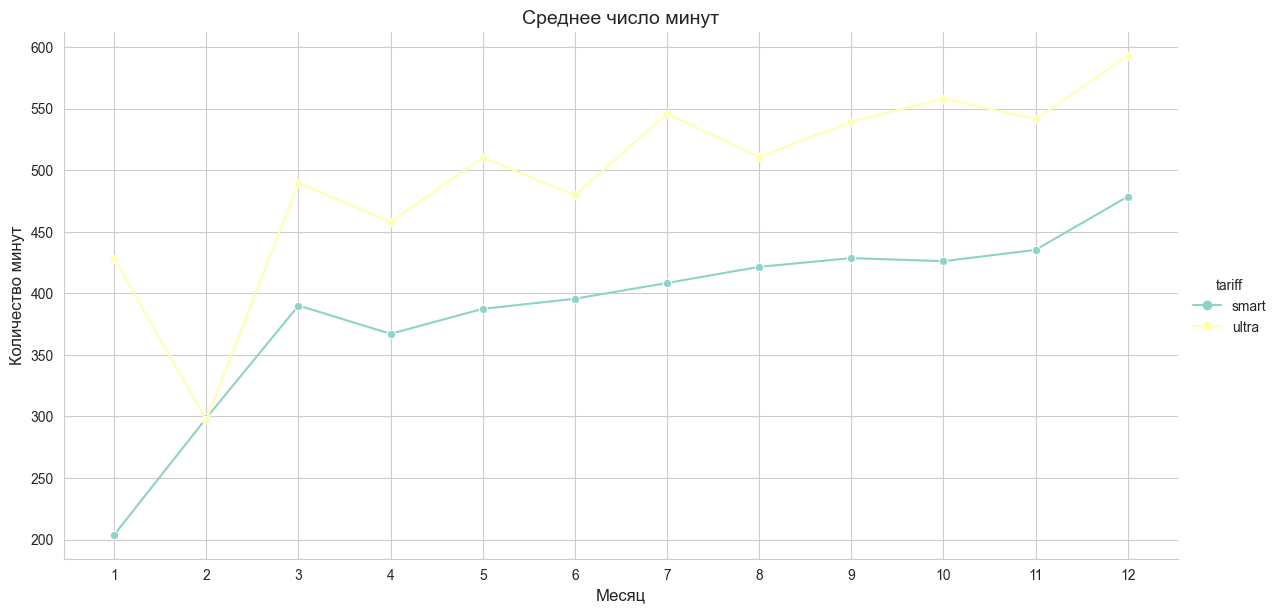

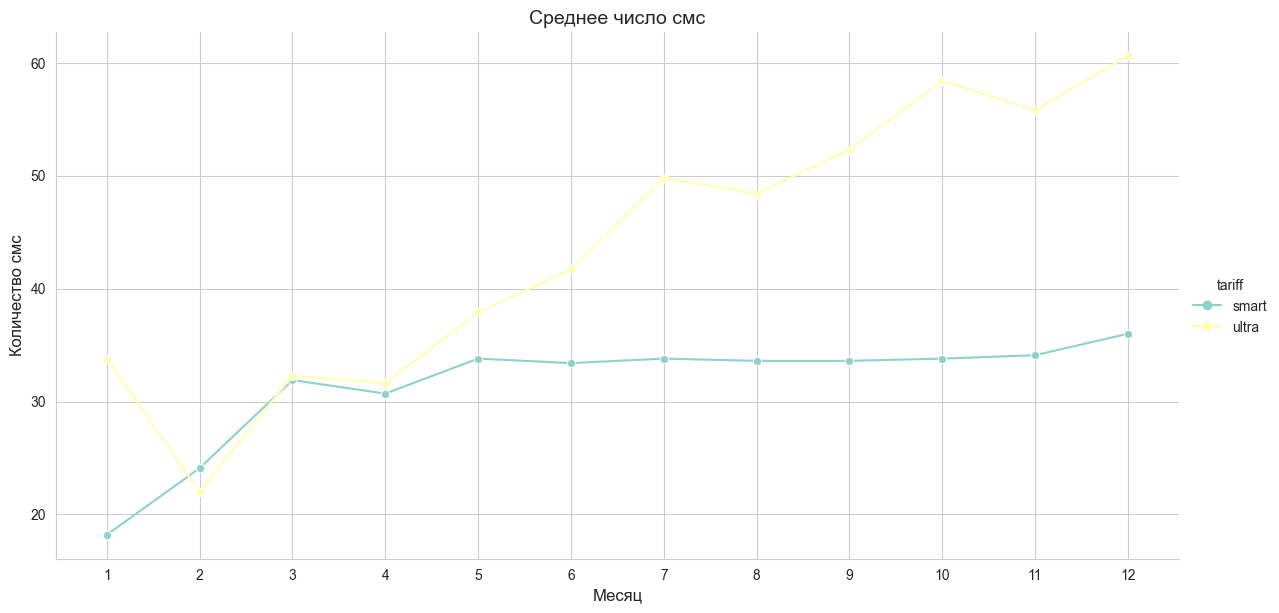

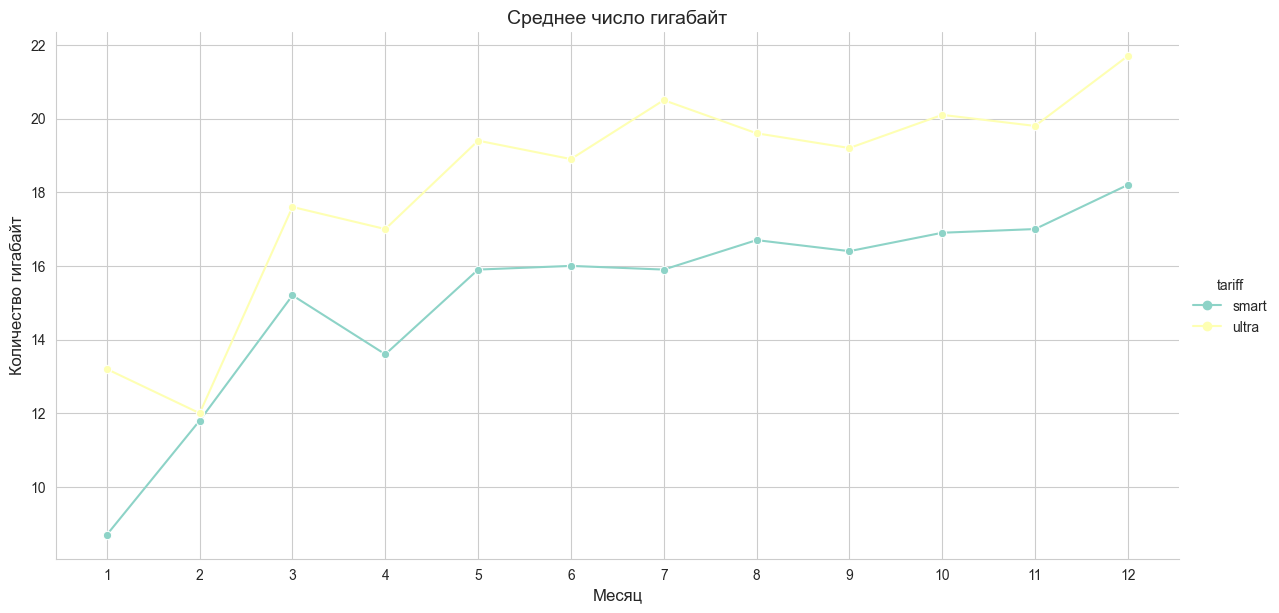

In [12]:
labels = ['минут', 'смс', 'гигабайт']
i = 0
for param in ['min_per_user', 'mes_per_user', 'gb_per_user']:
    sns.axes_style("whitegrid")
    sns.set_style(style = 'whitegrid')

    sns.relplot(data = united_grouped, x = "month", y = param,
                hue = "tariff", kind = "line", marker = 'o',
                height = 6, aspect = 2);

    plt.title("Среднее число " + labels[i], fontsize = 14)
    plt.xlabel('Месяц', fontsize = 12)
    plt.ylabel('Количество ' + labels[i], fontsize = 12)
    plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
    i += 1

### Посчитаем среднее количество, дисперсию и стандартное отклонение. Построим гистограммы. Опишем распределения

Разделим пользователей по тарифным планам и построим для них гистограмму по минутам, смс и мегабайтам.

<div class="alert alert-info"> 
Напишите в следующей ячейке код для чтения таблицы 'united' из файла 'united_correct.csv'
 </div>

In [13]:
united = pd.read_csv('united_correct.csv')
import pandas as pd
import numpy as np# напишите в этой ячейке код для чтения таблицы 'united' из файла 'united_correct.csv'


##### Тариф "Ультра"

In [14]:
ultra = (united
       .query('tariff == "ultra"')
       .pivot_table(index = ['user_id', 'month'], 
                    values = ['minutes_spent', 'messages_sent', 'gb_used'])
      )
ultra

gb_used  messages_sent  minutes_spent
user_id month                                       
1000    5          3.0           22.0          159.0
        6         23.0           60.0          172.0
        7         14.0           75.0          340.0
        8         14.0           81.0          408.0
        9         15.0           57.0          466.0
...                ...            ...            ...
1495    8          3.0           13.0           92.0
        9         33.0           82.0          813.0
        10        29.0           82.0         1030.0
        11        39.0           79.0          954.0
        12        23.0           84.0         1031.0

[985 rows x 3 columns]

In [15]:
analysis_u = ultra[['minutes_spent', 'messages_sent', 'gb_used']].describe()
analysis_u

,minutes_spent,messages_sent,gb_used
count,985.000000,985.000000,985.000000
mean,526.623350,49.363452,19.494416
std,317.606098,47.804457,9.853511
min,0.000000,0.000000,0.000000
25%,284.000000,6.000000,12.000000
50%,518.000000,38.000000,19.000000
75%,752.000000,79.000000,27.000000
max,1673.000000,224.000000,49.000000


<div class="alert alert-info"> 
Средние значения для тарифа "Ультра" (впишите полученные значения):
    
    - __ минут
    - __ смс
    - __ гигабайт
 </div>

<div class="alert alert-info"> 
Стандартные отклонения (впишите полученные значения):
    
    - __ минут
    - __ смс
    - __ гигабайт
 </div>

Найдем дисперсии для количества минут, смс и интернет-трафика:

In [16]:
np.var(ultra)

np.float64(88366.93490158353)

<div class="alert alert-info"> 
Дисперсии для тарифа **"Ультра"** (впишите полученные значения):
    
    - __ минут
    - __ смс
    - __ гигабайт
 </div>

Построим гистограммы для тарифа "Ультра"

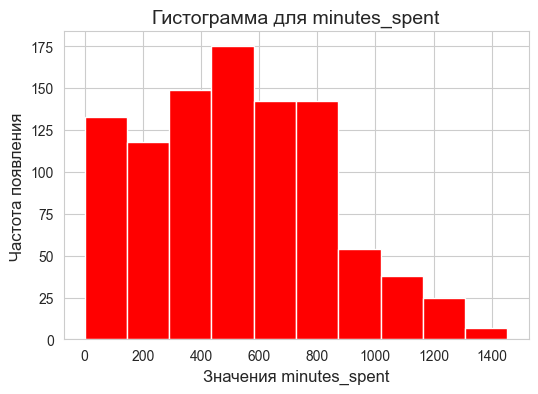

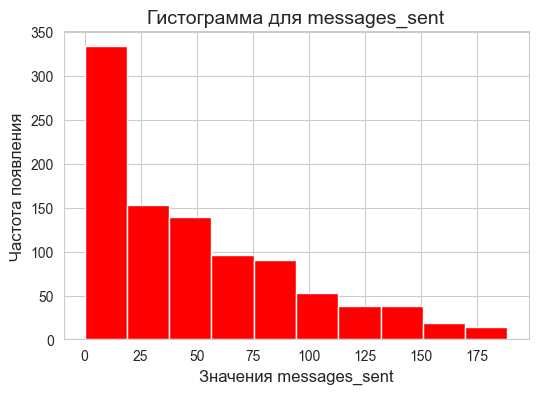

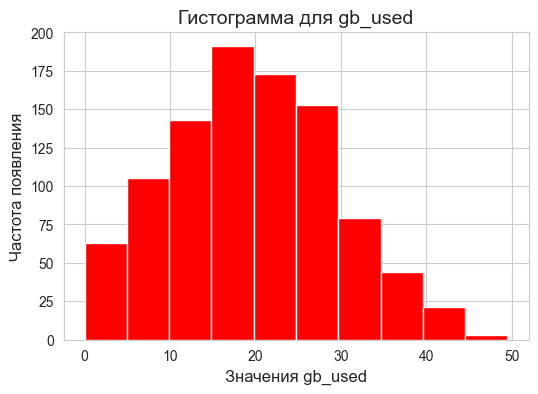

In [17]:
for column in analysis_u.columns:
    q1 = analysis_u[column]['25%']
    q3 = analysis_u[column]['75%']
    iqr = q3 - q1
    left = max(q1 - 1.5 * iqr, 0)
    right = q3 + 1.5 * iqr
    ultra = ultra.query('@left <= {0} <= @right'.format(column))
    ultra.hist(column, bins = 10, range = (left, right), figsize = (6, 4), grid = True, color = 'r')
    plt.xlabel('Значения ' + column, fontsize = 12)
    plt.ylabel('Частота появления', fontsize = 12)
    plt.title('Гистограмма для ' + column, fontsize = 14)

<div class="alert alert-success">
По полученным гистограммам можно сделать предварительные выводы:
    
- Распределение минут в тарифе "Ультра" похоже на нормальное, скошенное влево.
- Распределение количества смс - Пуассоновское.
- Распределение гигабайт - нормальное, немного скошенное влево.
 </div>

##### Тариф "Смарт"

In [18]:
smart = (united
       .query('tariff == "smart"')
       .pivot_table(index = ['user_id', 'month'], 
                    values = ['minutes_spent', 'messages_sent', 'gb_used'])
      )
smart

gb_used  messages_sent  minutes_spent
user_id month                                       
1001    11        18.0            0.0          430.0
        12        14.0            0.0          414.0
1002    6         11.0            4.0          117.0
        7         18.0           11.0          214.0
        8         20.0           13.0          289.0
...                ...            ...            ...
1498    10        21.0           42.0          247.0
1499    9          2.0           11.0           70.0
        10        18.0           48.0          449.0
        11        18.0           59.0          612.0
        12        13.0           66.0          492.0

[2229 rows x 3 columns]

In [19]:
analysis_s = smart[['minutes_spent', 'messages_sent', 'gb_used']].describe()
analysis_s

,minutes_spent,messages_sent,gb_used
count,2229.000000,2229.000000,2229.000000
mean,417.934948,33.384029,16.328847
std,190.313730,28.227876,5.747061
min,0.000000,0.000000,0.000000
25%,282.000000,10.000000,13.000000
50%,422.000000,28.000000,17.000000
75%,545.000000,51.000000,20.000000
max,1435.000000,143.000000,38.000000


<div class="alert alert-info"> 
Средние значения для тарифа "Смарт" (впишите полученные значения):
    
    - __ минут
    - __ смс
    - __ гигабайт
 </div>

<div class="alert alert-info"> 
Стандартные отклонения (впишите полученные значения):
    
    - __ минут
    - __ смс
    - __ гигабайт
 </div>

Найдем дисперсии для количества минут, смс и интернет-трафика:

In [20]:
np.var(smart)

np.float64(46728.373089175366)

<div class="alert alert-info"> 
Дисперсии для тарифа **"Ультра"** (впишите полученные значения):
    
    - __ минут
    - __ смс
    - __ гигабайт
 </div>

Построим гистограммы для тарифа "Смарт"

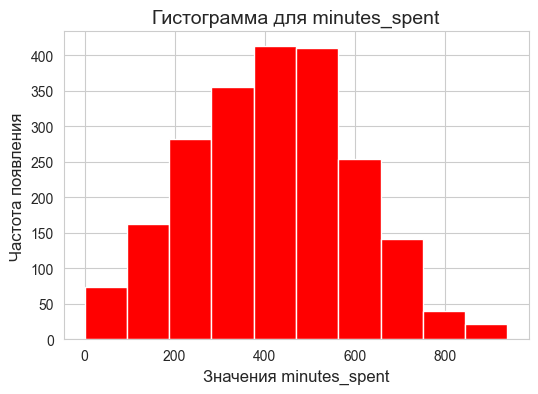

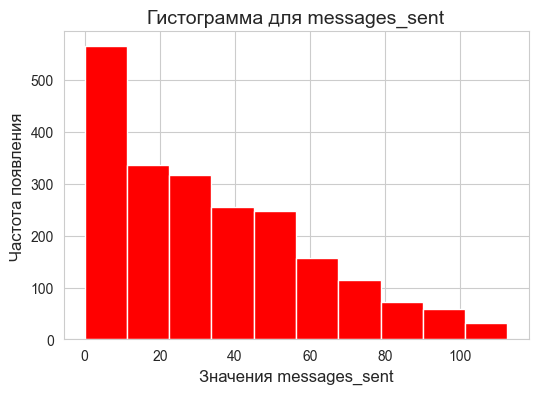

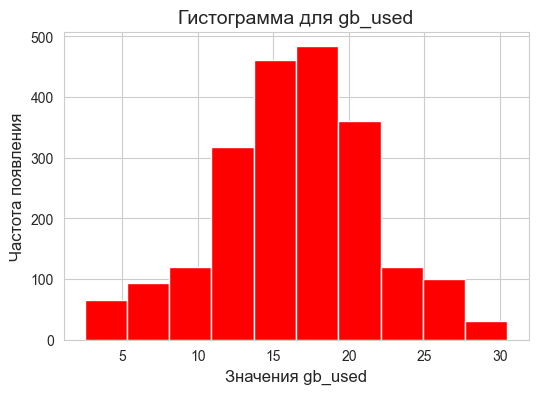

In [22]:
for column in analysis_s.columns:
    q1 = analysis_s[column]['25%']
    q3 = analysis_s[column]['75%']
    iqr = q3 - q1
    left = max(q1 - 1.5 * iqr, 0)
    right = q3 + 1.5 * iqr
    smart = smart.query('@left <= {0} <= @right'.format(column))
    smart.hist(column, bins = 10, range = (left, right), figsize = (6, 4), grid = True, color = 'r')
    plt.xlabel('Значения ' + column, fontsize = 12)
    plt.ylabel('Частота появления', fontsize = 12)
    plt.title('Гистограмма для ' + column, fontsize = 14)

<div class="alert alert-success">
По полученным гистограммам можно сделать предварительные выводы:
    
- Распределение минут в тарифе "Смарт" нормальное, скошенное влево.
- Распределение количества смс - Пуассоновское.
- Распределение гигабайт - нормальное.
 </div>

### Проверка гипотез

<div class="alert alert-info"> 
    
Нулевая гипотеза всегда формулируется как равенство. 
Альтернативная гипотеза противоположна нулевой и является неравенством (в данном случае она формулируется как "не равно").

Нам нужно проверить равенство средних двух генеральных совокупностей для парных выборок (двух тарифов). Чтобы проверить эту гипотезу применим функцию scipy.stats.ttest_rel().

Решение о принятии или отвержении нулевой гипотезы принимается по p-value. Это вероятность получить наблюдаемый результат при условии, что нулевая гипотеза верна. Общепринятые пороговые значения — 5% и 1%. Выберем пороговое значение 1%.

 </div>

#### Гипотеза: средние выручки пользователей тарифов «Ультра» и «Смарт» различаются

**Нулевая гипотеза**: средние выручки равны.

**Альтернативная гипотеза**: средние выручки различаются.

In [23]:
ultra_revenue = united.loc[united['tariff'] == 'ultra', 'revenue'].reset_index(drop = True)
len(ultra_revenue)

985

In [24]:
smart_revenue = united.loc[united['tariff'] == 'smart', 'revenue'].reset_index(drop = True)
len(smart_revenue)

2229

Для проверки гипотезы нам нужны выборки одинаковой длины. У нас получились выборки разной длины, поэтому из бОльшей выборки возьмем часть (случайным образом), равную меньшей выборке:

In [25]:
smart_revenue = smart_revenue.sample(len(ultra_revenue))

In [26]:
alpha = 0.01  # критический уровень статистической значимости

results = st.ttest_rel(ultra_revenue, smart_revenue)

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 3.1361217665854203e-125
Отвергаем нулевую гипотезу


##### Вывод: 

**Нулевая** гипотеза отвергнута. Это значит, что средние выручки различаются. 

Можно убедиться в этом:

<div class="alert alert-info"> 
    Напишите в следующей ячейке код для нахождения средней выручки тарифа Ультра (примените метод mean() к таблице ultra_revenue
 </div>

In [27]:
ultra_mean = ultra_revenue.mean()
print(f"Средняя выручка по тарифу 'Ультра': {ultra_mean}")# напишите в этой ячейке код для нахождения средней выручки тарифа Ультра (примените метод mean() к таблице ultra_revenue


Средняя выручка по тарифу 'Ультра': 2070.1522842639592


<div class="alert alert-info"> 
    Напишите в следующей ячейке код для нахождения средней выручки тарифа Смарт (примените метод mean() к таблице smart_revenue
 </div>

In [28]:
print("\n" + "=" * 50 + "\n")
ultra_mean = ultra_revenue.mean()
print(f"Средняя выручка по тарифу 'Ультра': {ultra_mean}")# напишите в этой ячейке код для нахождения средней выручки тарифа Смарт (примените метод mean() к таблице smart_revenue




Средняя выручка по тарифу 'Ультра': 2070.1522842639592


<div class="alert alert-success">
Средняя выручка по тарифу "Ультра" ____________, чем по тарифу "Смарт".
 </div>